In [8]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image
import torchvision
from pathlib import Path
from torchvision import transforms
from diffusers import DDPMScheduler, UNet2DModel, DDIMPipeline
from dataset import LatentAudioDataset



def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
EMBEDDINGS_PATH = Path("C:/Users/dzluk/stable-audio-tools/data/blackbird/embeddings")


# We'll train on 32-pixel square images, but you can try larger sizes too
image_size = 64
# You can lower your batch size if you're running out of GPU memory
batch_size = 4
epochs = 10

# Define data augmentations
# preprocess = transforms.Compose(
#     [
#         transforms.Resize((image_size, image_size)),  # Resize
#         transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
#         transforms.ToTensor(),  # Convert to tensor (0, 1)
#         transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
#     ]
# )

preprocess = transforms.Compose(
    [
        transforms.Lambda(lambda x: x[:, :, :64]),
        # transforms.ToTensor(),  # Convert to tensor (0, 1)
        # transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ]
)

dataset = LatentAudioDataset(EMBEDDINGS_PATH, normalize=False, transform=preprocess)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

In [3]:

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=1,  # the number of input channels, 3 for RGB images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device)

UNet2DModel(
  (conv_in): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\diffusers\configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:5, loss: 0.3965865973463302
Epoch:10, loss: 0.39906877981278527


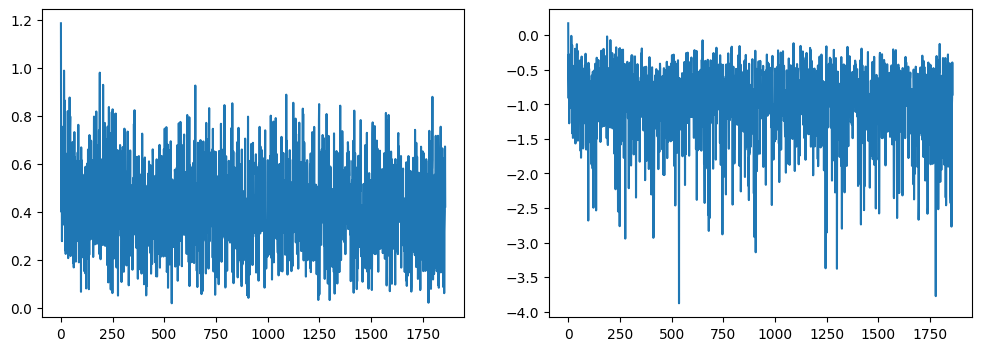

In [6]:
# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

losses = []

for epoch in range(epochs):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch.to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:01<00:00, 43.47it/s]


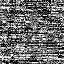

In [ ]:
image_pipe = DDIMPipeline(unet=model, scheduler=noise_scheduler)
image_pipe.save_pretrained("diffusers-latent-audio-pipeline")

# !! this sampling outputs numbers in the range 0 - 1. That doesn't work for the decoder (actual values are like -5 to 3 or something)
pipeline_output = image_pipe()
pipeline_output.images[0]

100%|██████████| 50/50 [00:03<00:00, 13.99it/s]


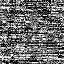

In [10]:
new_pipe = DDIMPipeline.from_pretrained("diffusers-latent-audio-pipeline")
new_pipeline_output = new_pipe()
pipeline_output.images[0]

In [22]:
sample = image_pipe(output_type="np")

100%|██████████| 50/50 [00:01<00:00, 37.01it/s]


In [24]:
sample['images'].squeeze()

array([[0.4800994 , 0.5669818 , 0.24677029, ..., 1.        , 0.8161152 ,
        0.72527516],
       [0.7322502 , 0.25338042, 0.03164312, ..., 0.38795045, 0.5882282 ,
        0.19577569],
       [0.45035973, 0.06465665, 0.        , ..., 0.74338955, 0.4348556 ,
        0.7580962 ],
       ...,
       [0.33455446, 0.19935274, 0.2032679 , ..., 0.8268652 , 1.        ,
        0.35140687],
       [0.21058491, 0.4052906 , 0.14843646, ..., 1.        , 0.5867618 ,
        1.        ],
       [0.0362345 , 0.7662095 , 0.44172242, ..., 0.3947268 , 0.21902749,
        0.6531255 ]], shape=(64, 64), dtype=float32)

In [ ]:
from DDIMPipeline import LukeDDIMPipeline

image_pipe = LukeDDIMPipeline.from_pretrained("diffusers-latent-audio-pipeline")
new_pipeline_output = image_pipe(output_type="np", use_clipped_model_output=False)
output = new_pipeline_output.images[0]
output.min(), output.max(), 

100%|██████████| 50/50 [00:03<00:00, 14.28it/s]


(np.float32(1.0), np.float32(-1.0))

In [28]:
pipeline_output.images[0].max()

AttributeError: 'Image' object has no attribute 'max'